In [1]:
import copy
import glob
import json
import random
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.models.model_predictions import woven_stiff_pred, cnn_stiff_pred
from cloth_fmri.utils.rdm import (
    build_model_rdm_from_stiffness_predictions,
    build_rdm,
    upper_to_square_rdm,
)
from cloth_fmri.utils.stats import (
    bootstrap_sample,
    get_mode_value,
    bootstrap_cor,
    calc_p,
)

# from cloth_fmri.utils.stats import (
#     bootstrap_cor,
#     calc_p,
# )

from cloth_fmri.utils.plot import (
    plot_bootstrap_violin,
    plot_model_rdm_matrix,
    plot_rdm_heatmap_from_upper,
    plot_two_distribution_violin,
)


random.seed(9)

SCENES = ["rotate", "wind", "ball", "drape"]

models = ["woven", "cnn"]
c_ls = ["0.1", "1.0", "10.0", "100.0"]
SUBJECT_LIST = CONFIG["subjects"]

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


# Fig. 4D
### Cross-scenario stiffness-similarity matrices for models

In [2]:
# ----------------------------------------------------
# Build model RDMs
# ----------------------------------------------------

model_pred_dict = {
    "woven": woven_stiff_pred,
    "cnn": cnn_stiff_pred,
}

models_rdm = {}
models_rdm_full = {}

for model in models:
    rdm_vec, rdm_full = build_model_rdm_from_stiffness_predictions(
        model_pred_dict[model],
        SCENES,
    )

    models_rdm[model] = rdm_vec
    models_rdm_full[model] = rdm_full

r_models, p_models = spearmanr(models_rdm["cnn"], models_rdm["woven"])

print(f"RDM prediction of Woven and DNN: r = {r_models}, p={p_models}")

RDM prediction of Woven and DNN: r = 0.028571428571428574, p=0.9571545189504373


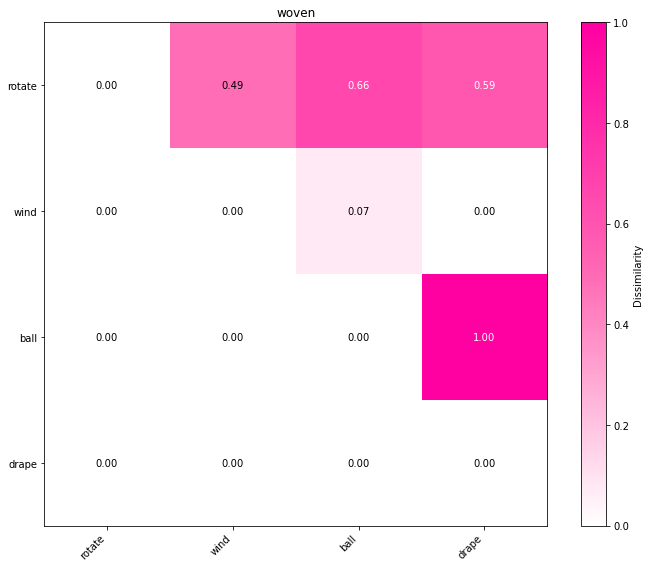

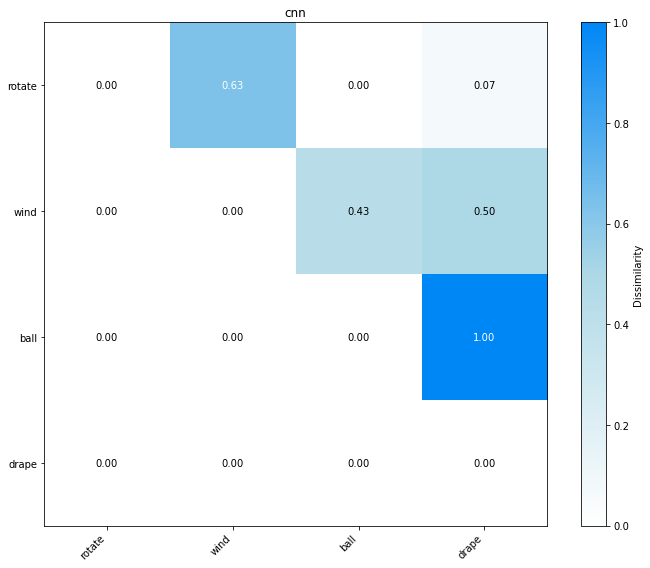

In [3]:
color_dict = {
    "cnn": ["#FFFFFF", "#ADD8E6", "#0087F6"],
    "woven": ["#FFFFFF", "#FF69B4", "#FF00A1"],
}

for model in models:
    colors = color_dict[model]

    cmap = LinearSegmentedColormap.from_list(
        f"{model}_rdm",
        colors,
        N=256,
    )

    fig, ax = plot_model_rdm_matrix(
        rdm_vec=models_rdm[model],
        labels=SCENES,
        title=model,
        cmap=cmap,
    )

    plt.show()

# Fig. 4B, 4C, 4E
# Supplementary Fig. 6D, 6E, 6F

In [4]:
human_rdm_root_dir = opj(
    CONFIG["output_root"],
    "analysis",
    "fig4",
)

rdm_colors_green = mcolors.LinearSegmentedColormap.from_list(
    "green_rdm",
    ["#dcf3e3", "#4bb062", "#276537"],
)

rdm_colors_bubbletea = mcolors.LinearSegmentedColormap.from_list(
    "bubbletea_rdm",
    ["#f4efe7", "#d3c6ad", "#5a4b38"],
)

rdm_colors_red = mcolors.LinearSegmentedColormap.from_list(
    "red_rdm",
    ["#fbe7e0", "#e8ab8f", "#843c2b"],
)

rdm_colors_dict = {
    "tower": rdm_colors_green,
    "v1": rdm_colors_bubbletea,
    "dot": rdm_colors_bubbletea,
    "loc": rdm_colors_red,
}

bootn = 10000
nsub = 24

best_r = {
    "tower": {"woven": [], "cnn": []},
    "v1": {"woven": [], "cnn": []},
    "loc": {"woven": [], "cnn": []},
}

best_bootstrap_r = {
    "tower": {"woven": [], "cnn": []},
    "v1": {"woven": [], "cnn": []},
    "loc": {"woven": [], "cnn": []},
}

best_human_rdm = {}
best_split_half = {}



-----------   tower   -----------
@@@ cor(neural, woven)=0.286, p=0.0028
@@@ cor(neural, cnn)=-0.064, p=0.4646
@@@ neural_split_half_cor=0.6792703881816333, p=0.0384


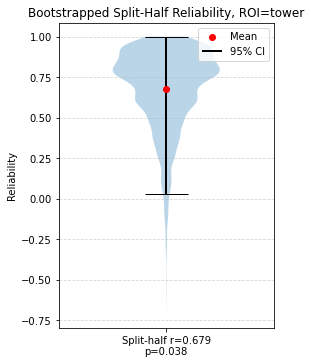

rdm-tower: [0.49712716 0.52917026 0.5071879  0.46639678 0.48810339 0.52213542]


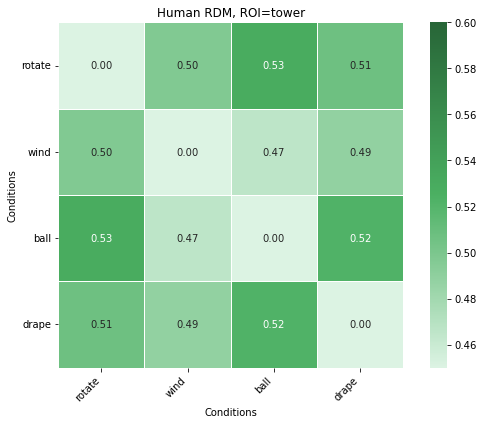

-------------


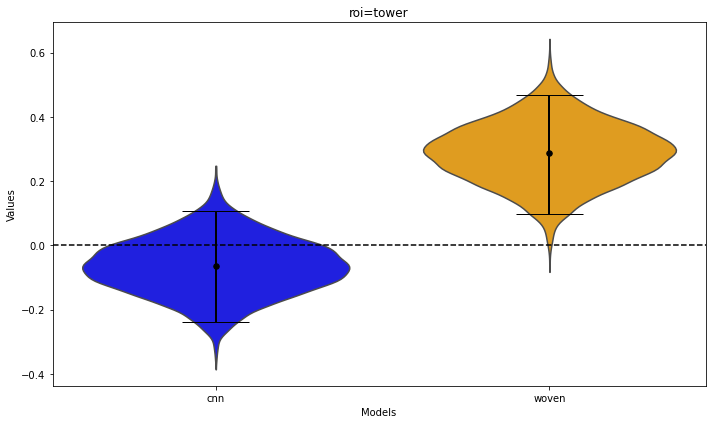



-----------   v1   -----------
@@@ cor(neural, woven)=0.063, p=0.4316
@@@ cor(neural, cnn)=0.219, p=0.0128
@@@ neural_split_half_cor=0.7036083454870147, p=0.023


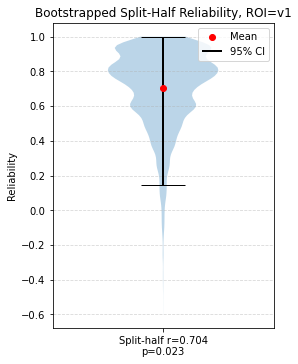

rdm-v1: [0.50807518 0.50641164 0.47856709 0.50747159 0.53808032 0.55972489]


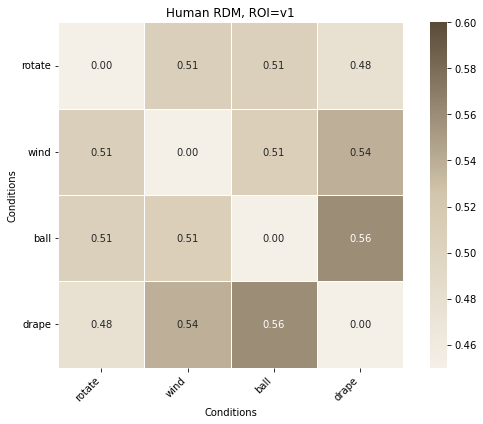

-------------


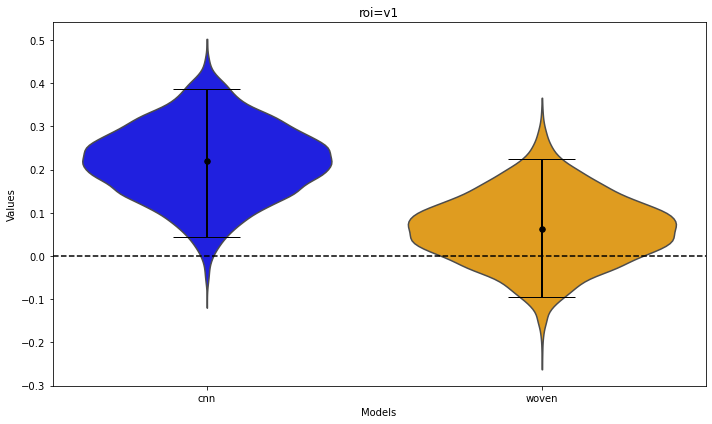



-----------   loc   -----------
@@@ cor(neural, woven)=0.076, p=0.4416
@@@ cor(neural, cnn)=-0.052, p=0.4228
@@@ neural_split_half_cor=0.47813737940971535, p=0.2062


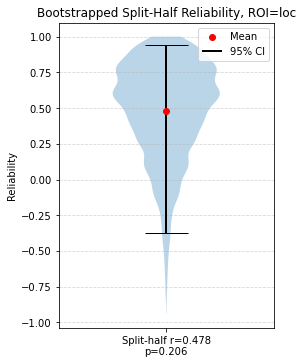

rdm-loc: [0.51293575 0.54878173 0.51005532 0.54400568 0.52060509 0.5225227 ]


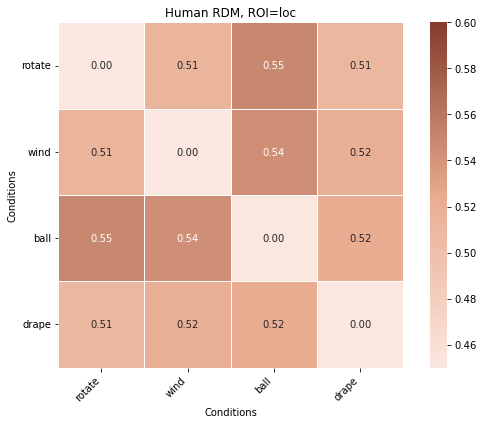

-------------


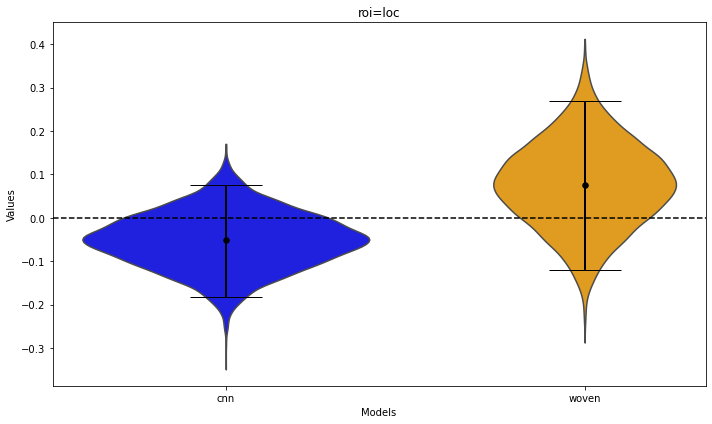

In [5]:
for roi in CONFIG["rois"]:
    print("\n")
    print(f"-----------   {roi}   -----------")

    best_split_half_cor = -1.0

    best_mean_woven_r = None
    best_mean_cnn_r = None

    best_bootstrap_cnn_r = None
    best_bootstrap_woven_r = None

    best_bootstrap_woven_p = None
    best_bootstrap_cnn_p = None

    best_split_half_p = None
    best_bootstrap_correlation = None
    best_rdm_avg_all_subs = None

    for c in c_ls:
        cur_human_rdm_dir = opj(human_rdm_root_dir, roi, f"C={c}")

        matching_files = glob.glob(f"{cur_human_rdm_dir}/*.json*")

        if len(matching_files) == 0:
            continue

        flag = True

        for file in matching_files:
            with open(file, "r") as f:
                data = json.load(f)

            if flag:
                flag = False
                all_data = copy.deepcopy(data)

                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene] = [
                            all_data[key_sub][key_scene]
                        ]

            else:
                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene].append(
                            data[key_sub][key_scene]
                        )

        # ----------------------------------------------------
        # Average over iterations using mode
        # ----------------------------------------------------
        all_data_mean = copy.deepcopy(all_data)

        for key_sub in all_data.keys():
            for key_scene in all_data[key_sub].keys():
                all_data_mean[key_sub][key_scene] = get_mode_value(
                    all_data[key_sub][key_scene]
                )

        # ----------------------------------------------------
        # Subject-level RDM and model correlations
        # ----------------------------------------------------
        rdm_all_subs = {}
        r_woven = {}
        r_cnn = {}

        for sub in SUBJECT_LIST:
            if sub in all_data_mean:
                rdm_all_subs[sub] = build_rdm(
                    all_data_mean[sub],
                    SCENES,
                    plot=False,
                )

                r_woven[sub] = spearmanr(
                    models_rdm["woven"],
                    rdm_all_subs[sub],
                )[0]

                r_cnn[sub] = spearmanr(
                    models_rdm["cnn"],
                    rdm_all_subs[sub],
                )[0]

        rdm_avg_all_subs = np.mean(
            np.array(list(rdm_all_subs.values())),
            axis=0,
        )

        mean_woven_r = round(np.mean(list(r_woven.values())), 3)
        mean_cnn_r = round(np.mean(list(r_cnn.values())), 3)

        # ----------------------------------------------------
        # Bootstrap model correlations
        # ----------------------------------------------------
        bootstrap_woven_r = [
            np.mean(bootstrap_sample(list(r_woven.values())))
            for _ in range(bootn)
        ]

        bootstrap_cnn_r = [
            np.mean(bootstrap_sample(list(r_cnn.values())))
            for _ in range(bootn)
        ]

        bootstrap_woven_p = calc_p(bootstrap_woven_r)
        bootstrap_cnn_p = calc_p(bootstrap_cnn_r)

        # ----------------------------------------------------
        # Split-half reliability
        # ----------------------------------------------------
        my_split_half_data = np.array(list(rdm_all_subs.values()))

        split_half_cor, split_half_p, bootstrap_correlations = bootstrap_cor(
            my_split_half_data,
            seed=0,
        )

        if split_half_cor >= best_split_half_cor:
            best_split_half_cor = split_half_cor
            best_split_half_p = split_half_p

            best_mean_cnn_r = mean_cnn_r
            best_mean_woven_r = mean_woven_r

            best_bootstrap_cnn_p = bootstrap_cnn_p
            best_bootstrap_woven_p = bootstrap_woven_p

            best_bootstrap_correlation = dc(bootstrap_correlations)
            best_bootstrap_cnn_r = dc(bootstrap_cnn_r)
            best_bootstrap_woven_r = dc(bootstrap_woven_r)

            best_rdm_avg_all_subs = dc(rdm_avg_all_subs)

            best_r[roi]["woven"] = list(r_woven.values())
            best_r[roi]["cnn"] = list(r_cnn.values())

            best_bootstrap_r[roi]["woven"] = dc(bootstrap_woven_r)
            best_bootstrap_r[roi]["cnn"] = dc(bootstrap_cnn_r)

    # ----------------------------------------------------
    # Save best result
    # ----------------------------------------------------
    best_human_rdm[roi] = dc(best_rdm_avg_all_subs)

    best_split_half[roi] = {
        "r": best_split_half_cor,
        "p": best_split_half_p,
        "bootstrap": dc(best_bootstrap_correlation),
    }

    print(f"@@@ cor(neural, woven)={best_mean_woven_r}, p={best_bootstrap_woven_p}")
    print(f"@@@ cor(neural, cnn)={best_mean_cnn_r}, p={best_bootstrap_cnn_p}")
    print(f"@@@ neural_split_half_cor={best_split_half_cor}, p={best_split_half_p}")

    # ----------------------------------------------------
    # Violin plot for split-half reliability
    # ----------------------------------------------------
    fig, ax = plot_bootstrap_violin(
        best_bootstrap_correlation,
        best_split_half_cor,
        title=f"Bootstrapped Split-Half Reliability, ROI={roi}",
        ylabel="Reliability",
    )

    ax.set_xticklabels([
        f"Split-half r={best_split_half_cor:.3f}\np={best_split_half_p:.3f}"
    ])

    plt.show()

    # ----------------------------------------------------
    # Plot human RDM
    # ----------------------------------------------------
    print(f"rdm-{roi}: {best_rdm_avg_all_subs}")

    fig, ax = plot_rdm_heatmap_from_upper(
        upper_rdm=best_rdm_avg_all_subs,
        labels=SCENES,
        cmap=rdm_colors_dict[roi],
        title=f"Human RDM, ROI={roi}",
        norm=Normalize(vmin=0.45, vmax=0.6),
        annot=True,
        figsize=(8, 6),
    )

    plt.show()
    print("-------------")

    # ----------------------------------------------------
    # Violin plot CNN vs Woven
    # ----------------------------------------------------
    data = np.array([
        best_bootstrap_r[roi]["cnn"],
        best_bootstrap_r[roi]["woven"],
    ]).T

    data_df = pd.DataFrame(data, columns=["cnn", "woven"])

    fig, ax = plot_two_distribution_violin(
        data_df=data_df,
        cols=["cnn", "woven"],
        title=f"roi={roi}",
        ylabel="Values",
        palette=("blue", "orange"),
    )

    plt.show()

In [6]:
df = pd.DataFrame({
    "loc_cnn": best_r["loc"]["cnn"],
    "loc_woven": best_r["loc"]["woven"],
    "phy_cnn": best_r["tower"]["cnn"],
    "phy_woven": best_r["tower"]["woven"],
})

n_subjects = len(df)
df["subject"] = range(1, n_subjects + 1)

df_long = pd.melt(
    df,
    id_vars="subject",
    value_vars=["loc_cnn", "loc_woven", "phy_cnn", "phy_woven"],
    var_name="condition",
    value_name="value",
)

df_long[["region", "model"]] = df_long["condition"].str.split("_", expand=True)

aov = pg.rm_anova(
    dv="value",
    within=["region", "model"],
    subject="subject",
    data=df_long,
    detailed=True,
)

print("##### Anova: Physics vs loc ##### \n")
print(aov)

##### Anova: Physics vs loc ##### 

           Source        SS  ddof1  ddof2        MS         F     p-unc  \
0          region  0.237172      1     23  0.237172  1.507815  0.231892   
1           model  1.376205      1     23  1.376205  5.292905  0.030818   
2  region * model  0.296226      1     23  0.296226  2.637649  0.117985   

   p-GG-corr       ng2  eps  
0   0.231892  0.013341  1.0  
1   0.030818  0.072750  1.0  
2   0.117985  0.016607  1.0  


In [7]:
df = pd.DataFrame({
    "v1_cnn": best_r["v1"]["cnn"],
    "v1_woven": best_r["v1"]["woven"],
    "phy_cnn": best_r["tower"]["cnn"],
    "phy_woven": best_r["tower"]["woven"],
})

n_subjects = len(df)
df["subject"] = range(1, n_subjects + 1)

df_long = pd.melt(
    df,
    id_vars="subject",
    value_vars=["v1_cnn", "v1_woven", "phy_cnn", "phy_woven"],
    var_name="condition",
    value_name="value",
)

df_long[["region", "model"]] = df_long["condition"].str.split("_", expand=True)

aov = pg.rm_anova(
    dv="value",
    within=["region", "model"],
    subject="subject",
    data=df_long,
    detailed=True,
)

print("##### Anova: Physics vs V1 ##### \n")
print(aov)

##### Anova: Physics vs V1 ##### 

           Source        SS  ddof1  ddof2        MS         F     p-unc  \
0          region  0.021523      1     23  0.021523  0.124081  0.727857   
1           model  0.228914      1     23  0.228914  0.983088  0.331755   
2  region * model  1.534960      1     23  1.534960  8.109721  0.009110   

   p-GG-corr       ng2  eps  
0   0.727857  0.001211  1.0  
1   0.331755  0.012735  1.0  
2   0.009110  0.079606  1.0  
